Selected countries:
- Benin
- Burkina Faso
- Mali
- Central African Republic
- Democratic Republic of the Congo
- Burundi
- Niger
- Mozambique
- Malawi
- Nigeria
- Guinea
- Sierra Leone


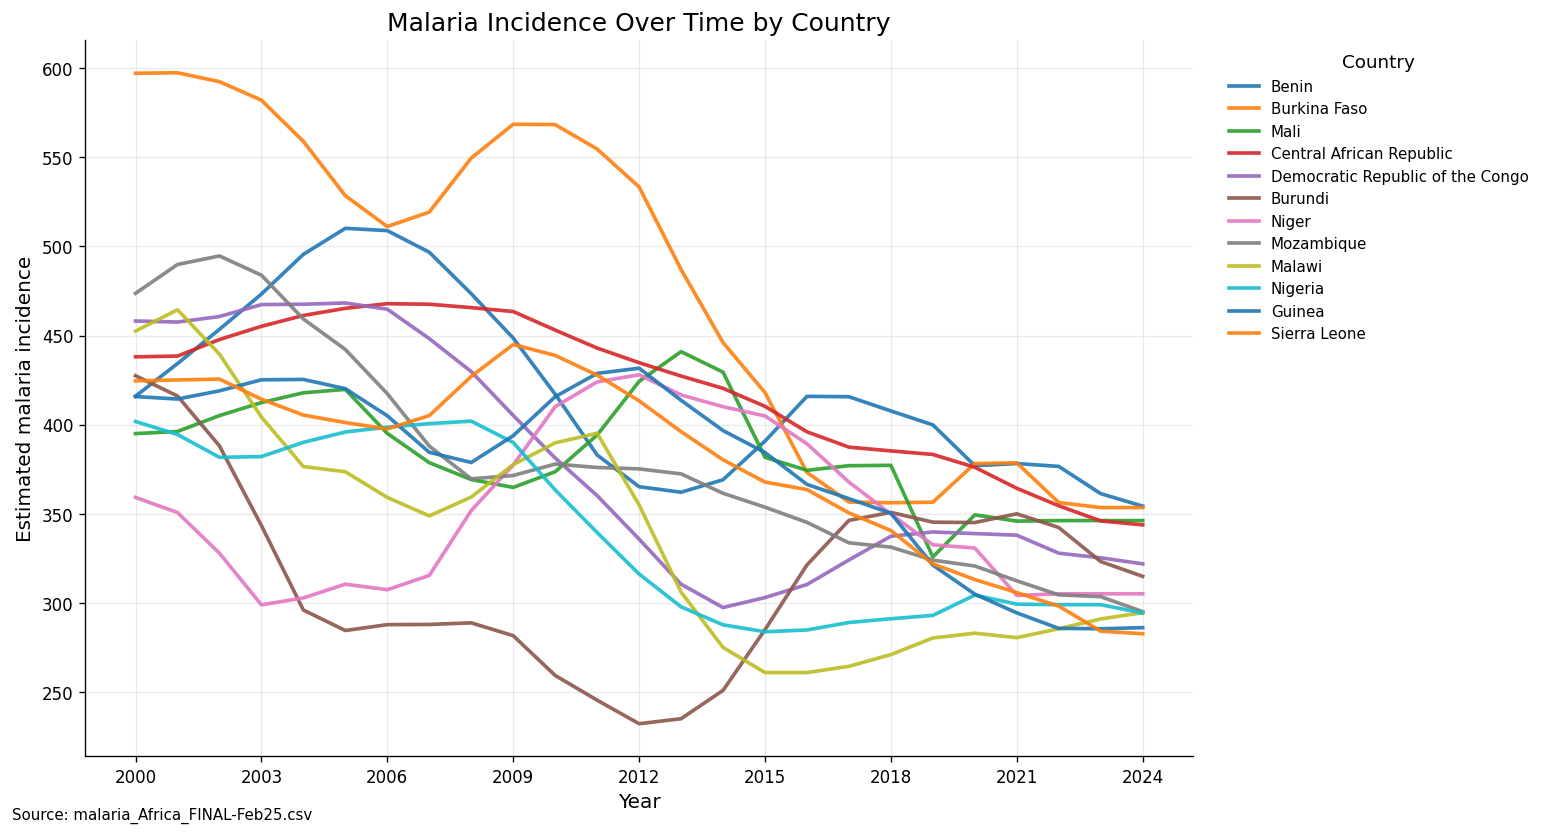

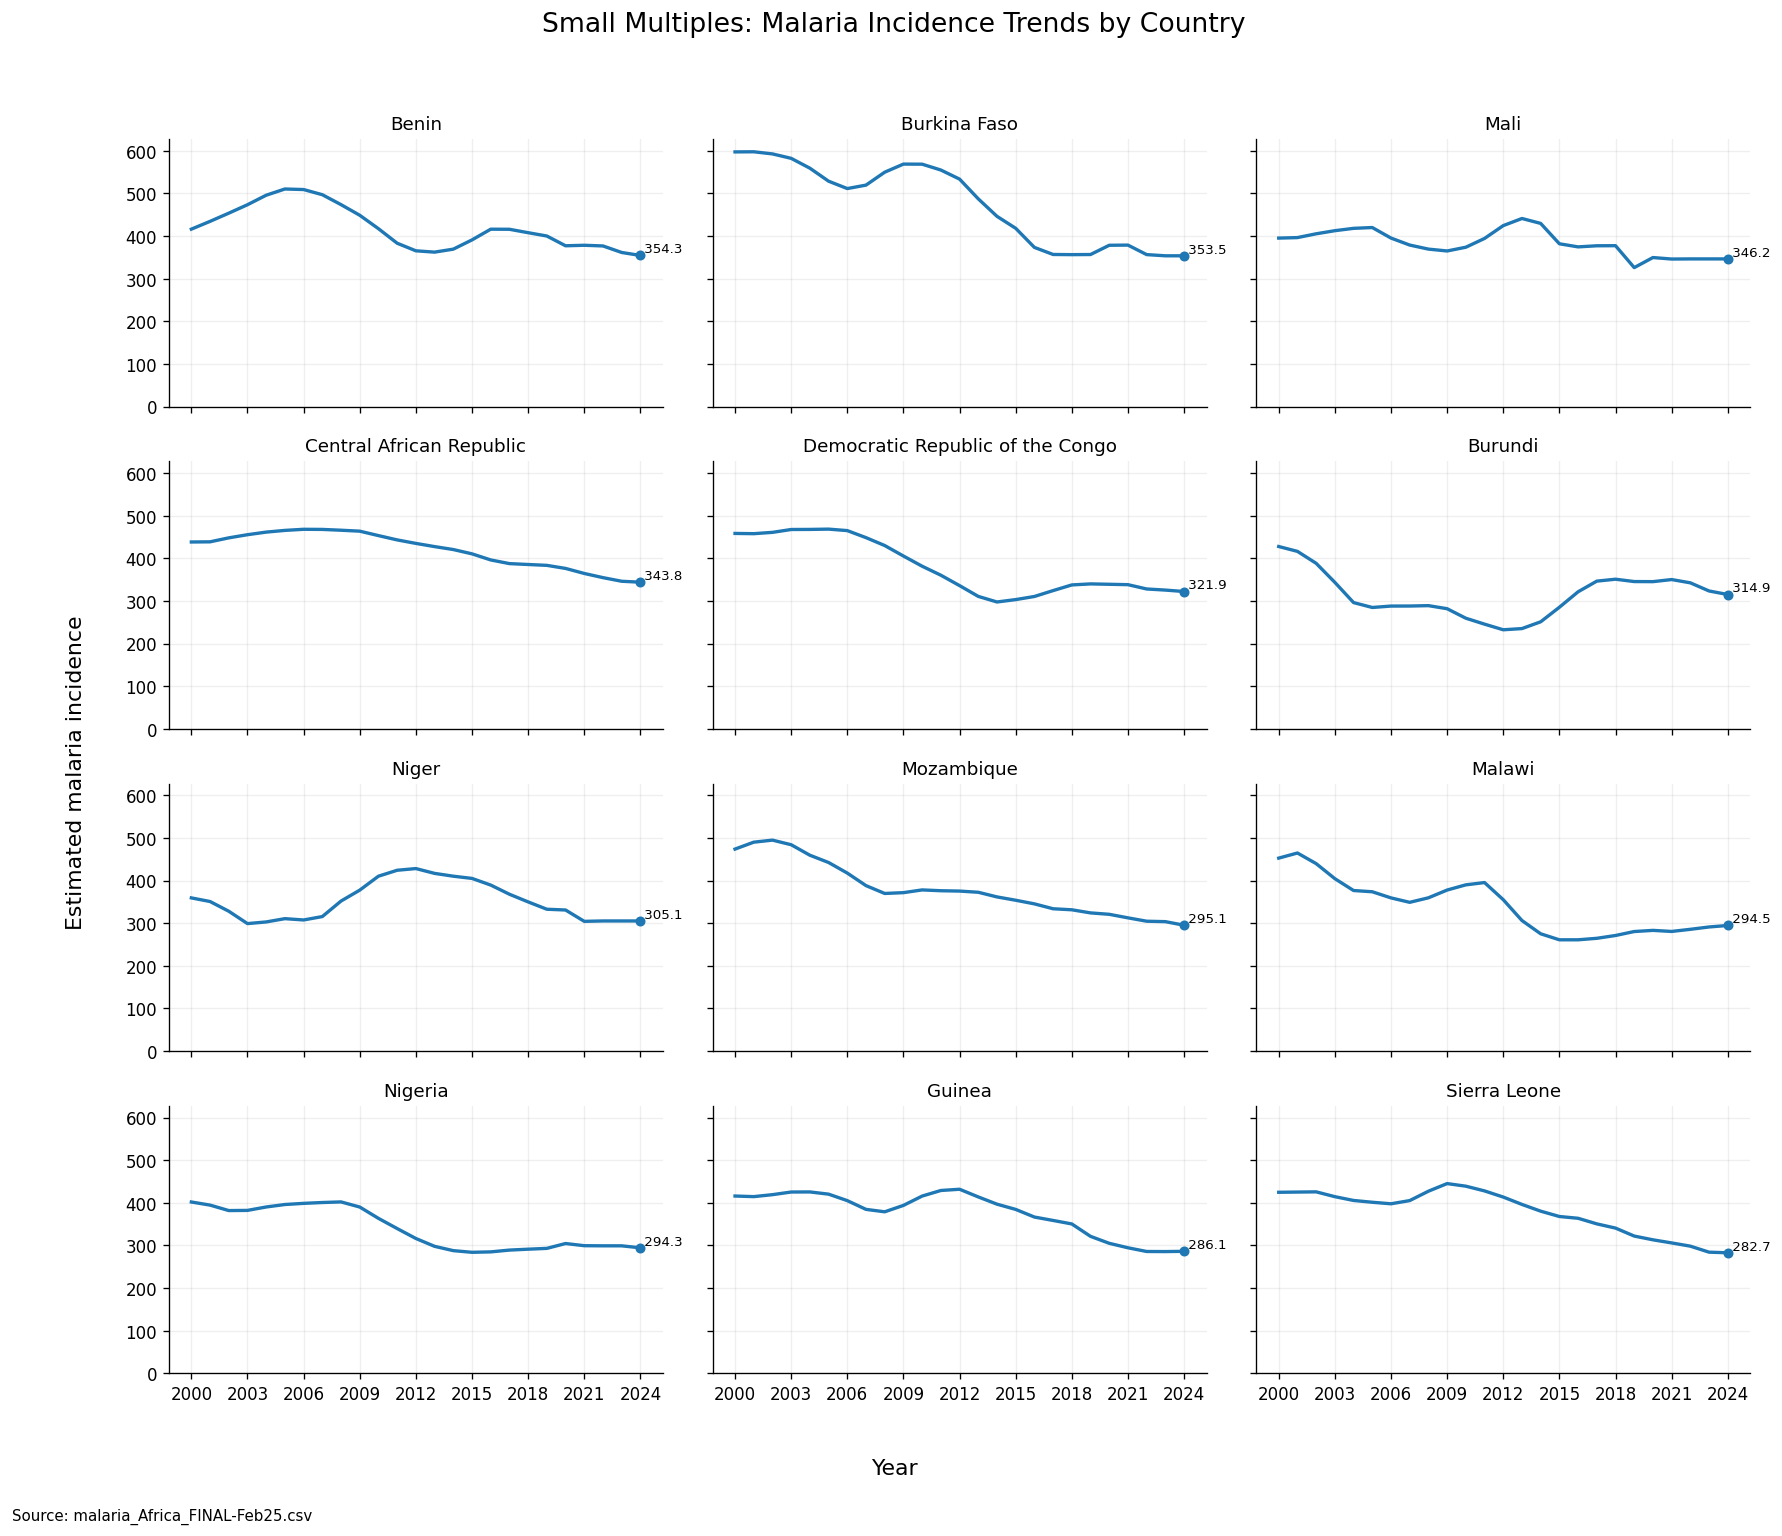

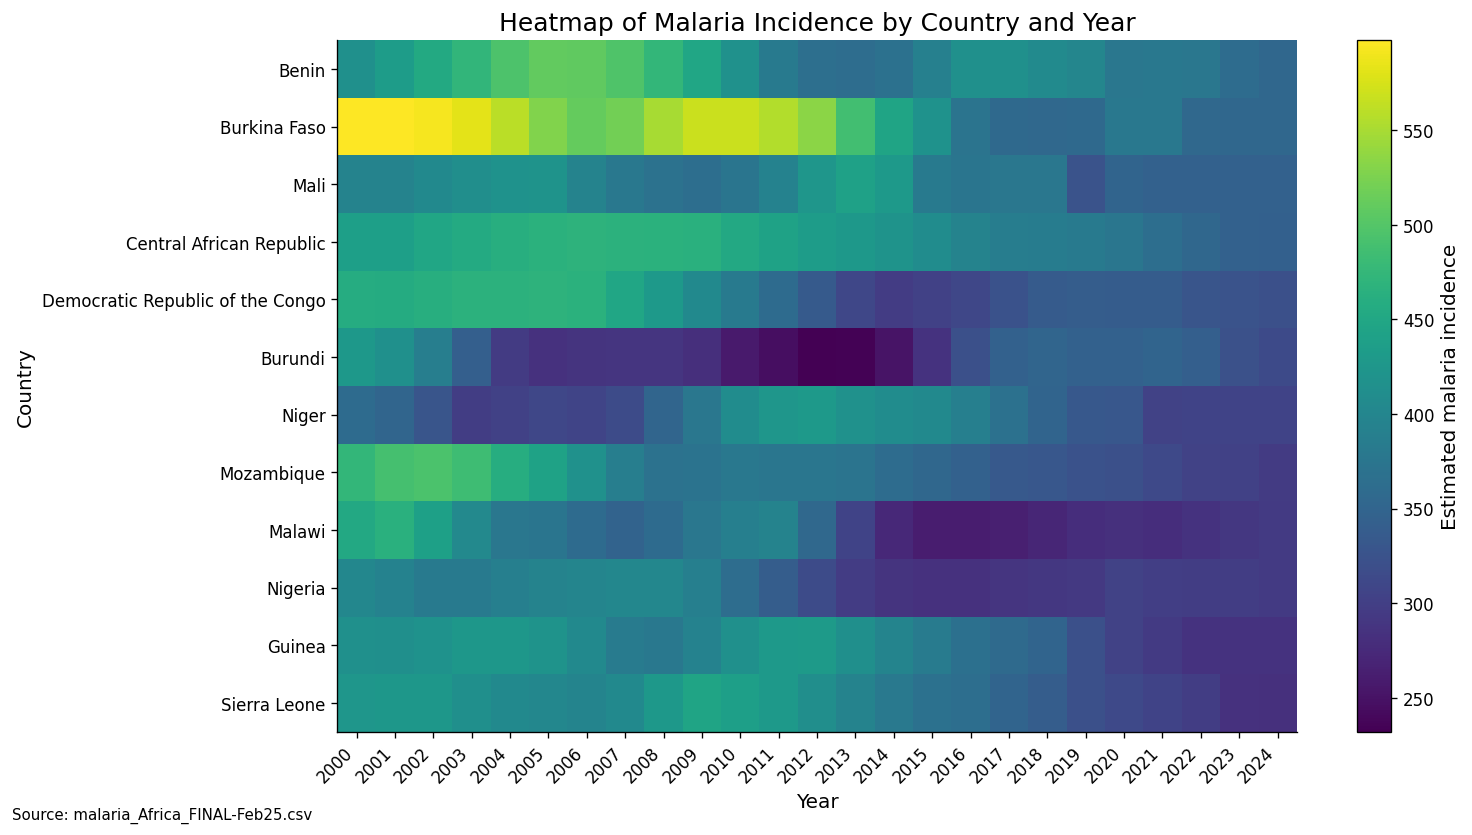

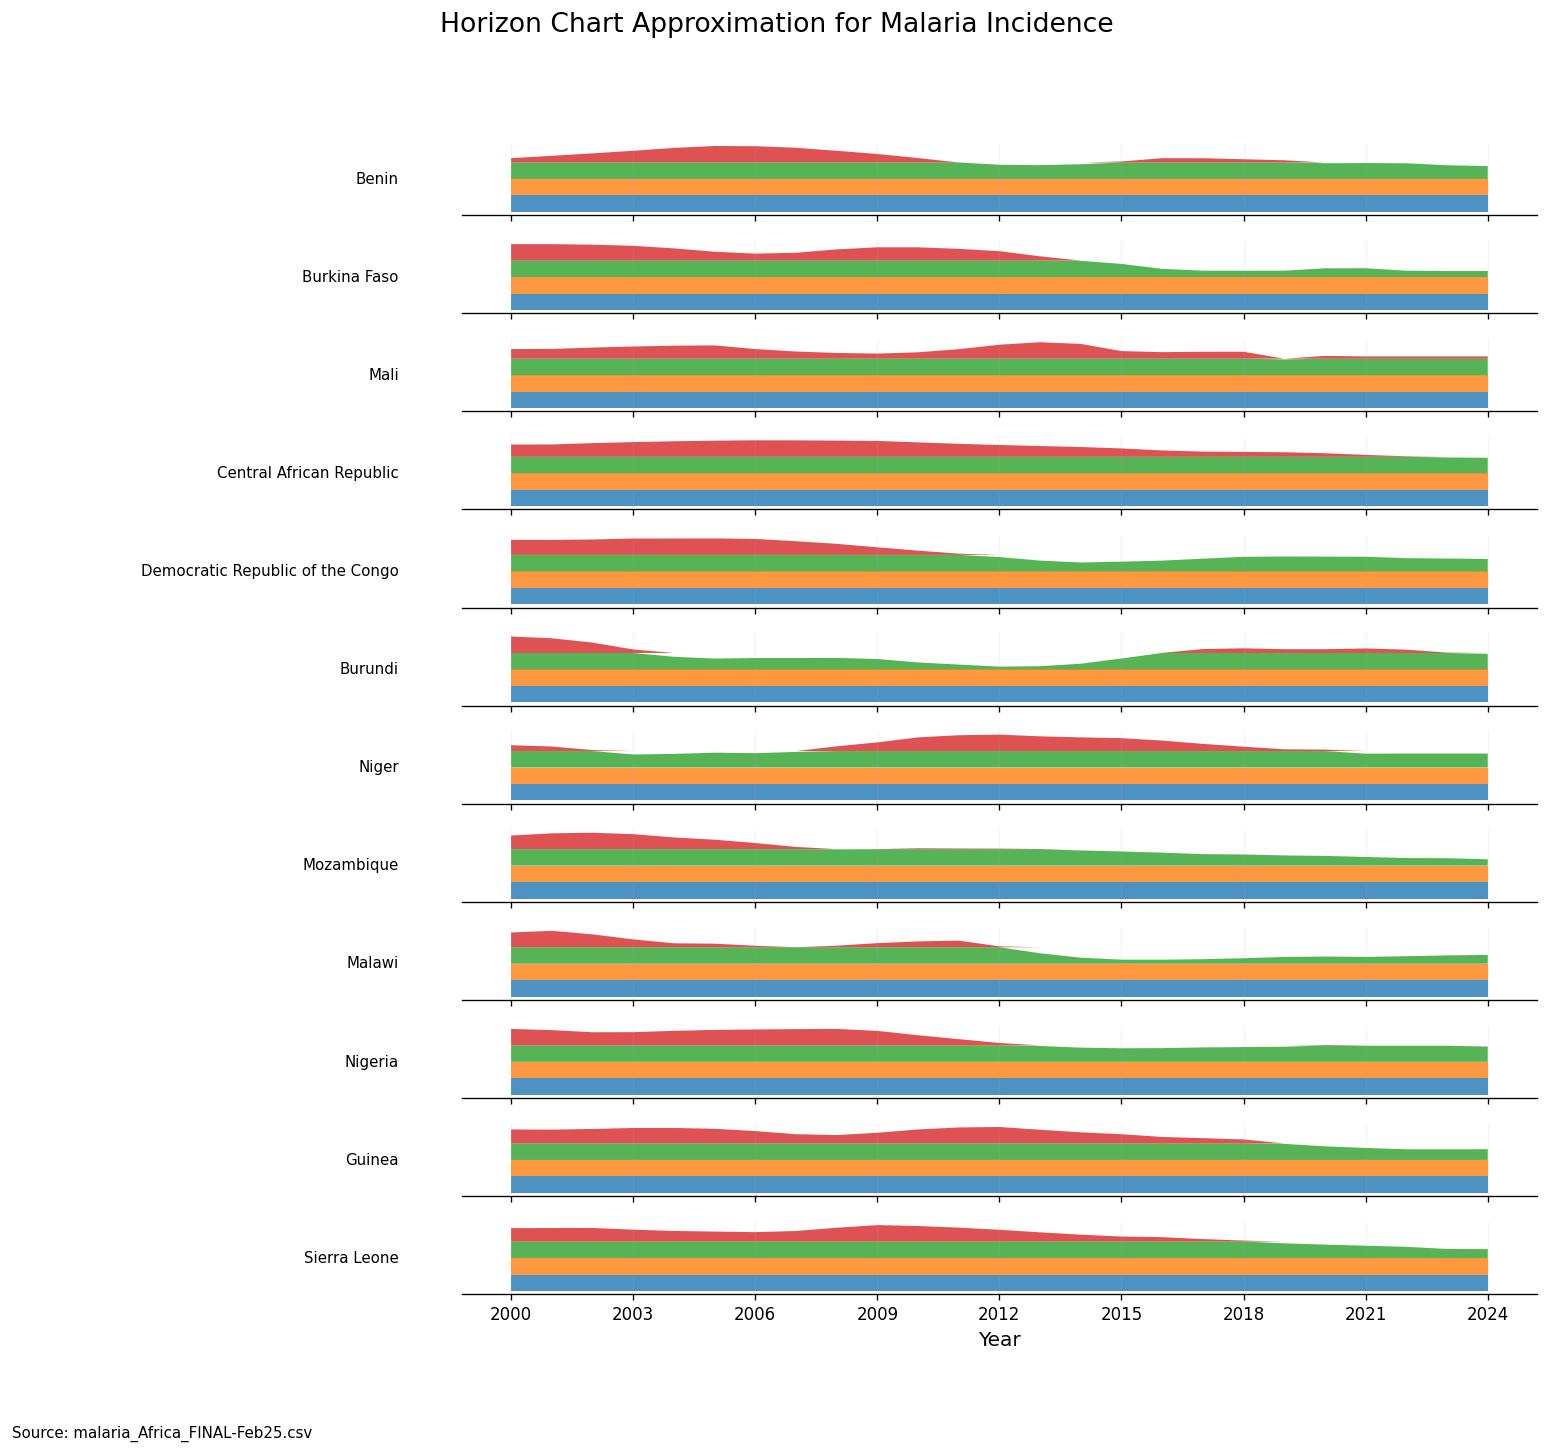

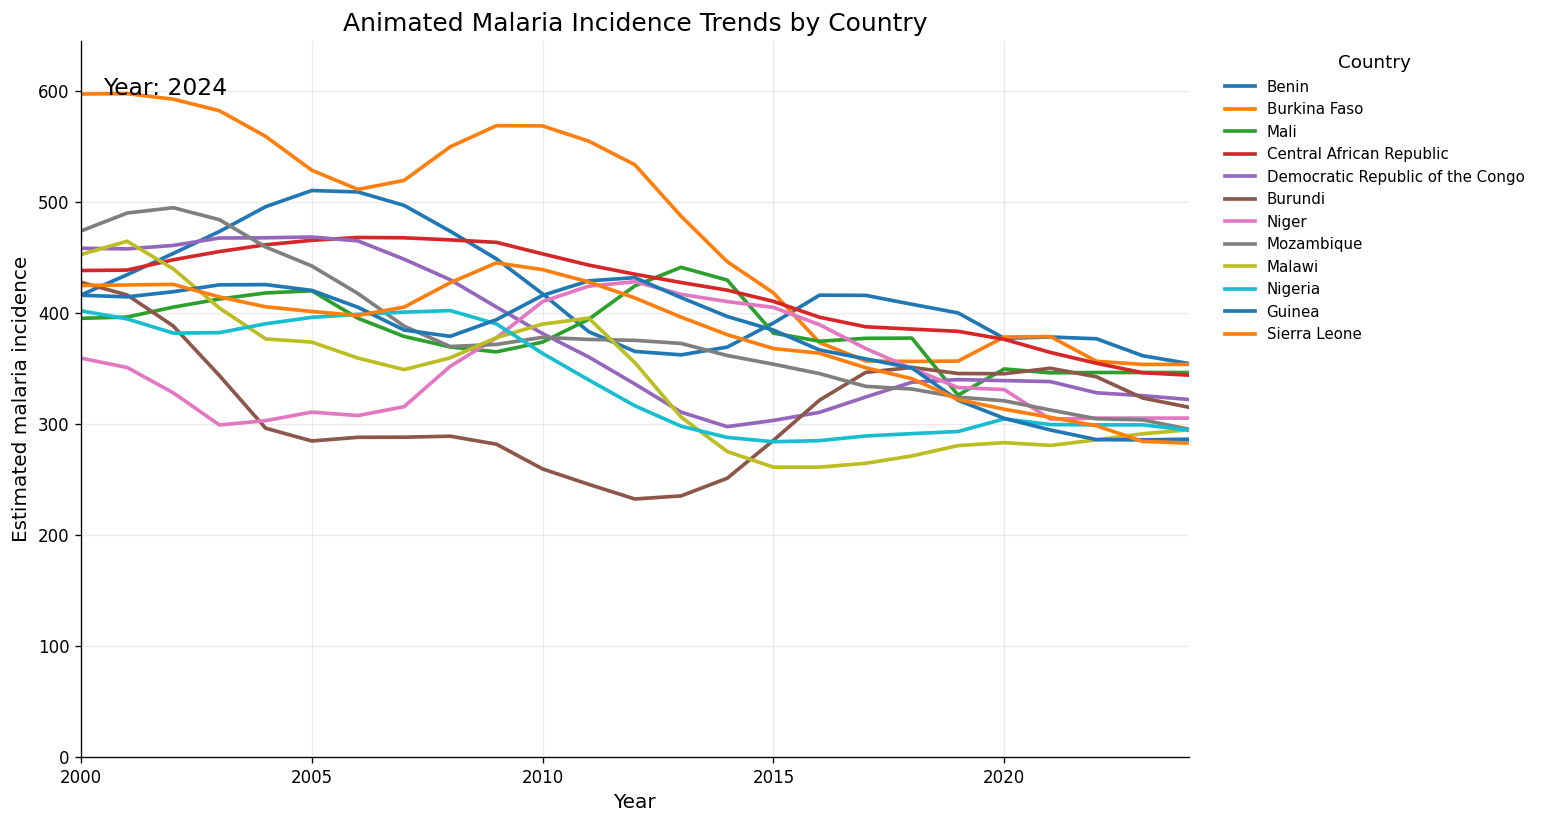

Saved animation to: figures/05_animated_line_chart.gif

All outputs saved to: figures


In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# =========================================================
# Publication-ready malaria time series visualization suite
# =========================================================

FILE_PATH = "/content/malaria_Africa_FINAL-Feb25.csv"
OUTPUT_DIR = "figures"
TOP_N = 12
VALUE_COL = "malaria_est_incidence"
COUNTRY_COL = "Country"
YEAR_COL = "Year"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ---------------------------------------------------------
# 1. Load and clean
# ---------------------------------------------------------
def load_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path)

    required_cols = [COUNTRY_COL, YEAR_COL, VALUE_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[required_cols].copy()
    df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce")
    df[VALUE_COL] = pd.to_numeric(df[VALUE_COL], errors="coerce")
    df[COUNTRY_COL] = df[COUNTRY_COL].astype(str).str.strip()

    df = df.dropna(subset=[COUNTRY_COL, YEAR_COL, VALUE_COL])
    df[YEAR_COL] = df[YEAR_COL].astype(int)

    # Keep only countries with at least 2 years of data
    counts = df.groupby(COUNTRY_COL)[YEAR_COL].nunique()
    valid_countries = counts[counts >= 2].index
    df = df[df[COUNTRY_COL].isin(valid_countries)].copy()

    df = df.sort_values([COUNTRY_COL, YEAR_COL]).reset_index(drop=True)
    return df


# ---------------------------------------------------------
# 2. Choose countries to display
# ---------------------------------------------------------
def select_top_countries(df: pd.DataFrame, top_n: int = 12) -> list[str]:
    latest_year = df[YEAR_COL].max()
    latest = df[df[YEAR_COL] == latest_year].copy()

    top_countries = (
        latest.groupby(COUNTRY_COL)[VALUE_COL]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )
    return top_countries


# ---------------------------------------------------------
# 3. Shared formatting helpers
# ---------------------------------------------------------
def apply_clean_style():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })


def add_source_note(fig, text="Source: malaria_Africa_FINAL-Feb25.csv"):
    fig.text(0.01, 0.01, text, ha="left", va="bottom", fontsize=9)


def nice_year_ticks(years):
    years = sorted(years)
    if len(years) <= 12:
        return years
    step = max(1, len(years) // 8)
    return years[::step]


# ---------------------------------------------------------
# 4. Line chart
# ---------------------------------------------------------
def plot_line_chart(df: pd.DataFrame, countries: list[str]):
    data = df[df[COUNTRY_COL].isin(countries)].copy()
    years = sorted(data[YEAR_COL].unique())

    fig, ax = plt.subplots(figsize=(13, 7))

    for country in countries:
        g = data[data[COUNTRY_COL] == country]
        ax.plot(
            g[YEAR_COL],
            g[VALUE_COL],
            linewidth=2.2,
            alpha=0.9,
            label=country
        )

    ax.set_title("Malaria Incidence Over Time by Country")
    ax.set_xlabel("Year")
    ax.set_ylabel("Estimated malaria incidence")
    ax.set_xticks(nice_year_ticks(years))
    ax.grid(True, alpha=0.25)

    ax.legend(
        title="Country",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
        ncol=1
    )

    fig.tight_layout()
    add_source_note(fig)
    out = os.path.join(OUTPUT_DIR, "01_line_chart.png")
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ---------------------------------------------------------
# 5. Small multiples
# ---------------------------------------------------------
def plot_small_multiples(df: pd.DataFrame, countries: list[str]):
    data = df[df[COUNTRY_COL].isin(countries)].copy()
    years = sorted(data[YEAR_COL].unique())
    n = len(countries)

    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(15, 3.2 * rows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    y_max = data[VALUE_COL].max() * 1.05

    for ax, country in zip(axes, countries):
        g = data[data[COUNTRY_COL] == country]

        ax.plot(g[YEAR_COL], g[VALUE_COL], linewidth=2.0)
        ax.set_title(country, fontsize=11, pad=6)
        ax.set_ylim(0, y_max)
        ax.grid(True, alpha=0.2)

        # highlight latest point
        latest = g.sort_values(YEAR_COL).iloc[-1]
        ax.scatter(latest[YEAR_COL], latest[VALUE_COL], s=25, zorder=3)
        ax.text(
            latest[YEAR_COL],
            latest[VALUE_COL],
            f" {latest[VALUE_COL]:.1f}",
            fontsize=8,
            va="bottom"
        )

    for ax in axes[n:]:
        ax.axis("off")

    for ax in axes[:n]:
        ax.set_xticks(nice_year_ticks(years))

    fig.suptitle("Small Multiples: Malaria Incidence Trends by Country", y=0.995, fontsize=16)
    fig.supxlabel("Year", y=0.04)
    fig.supylabel("Estimated malaria incidence", x=0.04)

    fig.tight_layout(rect=[0.04, 0.05, 1, 0.97])
    add_source_note(fig)
    out = os.path.join(OUTPUT_DIR, "02_small_multiples.png")
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ---------------------------------------------------------
# 6. Heatmap (Country x Year)
# ---------------------------------------------------------
def plot_heatmap(df: pd.DataFrame, countries: list[str]):
    data = df[df[COUNTRY_COL].isin(countries)].copy()

    pivot = (
        data.pivot_table(
            index=COUNTRY_COL,
            columns=YEAR_COL,
            values=VALUE_COL,
            aggfunc="mean"
        )
        .reindex(countries)
    )

    fig, ax = plt.subplots(figsize=(13, 7))
    im = ax.imshow(pivot.values, aspect="auto", interpolation="nearest")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Estimated malaria incidence")

    ax.set_title("Heatmap of Malaria Incidence by Country and Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Country")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns.astype(int), rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    fig.tight_layout()
    add_source_note(fig)
    out = os.path.join(OUTPUT_DIR, "03_heatmap.png")
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ---------------------------------------------------------
# 7. Horizon chart (matplotlib approximation)
# ---------------------------------------------------------
def plot_horizon_chart(df: pd.DataFrame, countries: list[str], bands: int = 4):
    data = df[df[COUNTRY_COL].isin(countries)].copy()
    years = sorted(data[YEAR_COL].unique())
    n = len(countries)

    fig, axes = plt.subplots(
        n, 1,
        figsize=(13, 0.8 * n + 2.5),
        sharex=True
    )

    if n == 1:
        axes = [axes]

    for ax, country in zip(axes, countries):
        g = data[data[COUNTRY_COL] == country].sort_values(YEAR_COL)
        x = g[YEAR_COL].values
        y = g[VALUE_COL].values.astype(float)

        ymin = 0
        ymax = np.nanmax(y)
        band_height = max((ymax - ymin) / bands, 1e-9)

        for b in range(bands):
            lower = ymin + b * band_height
            clipped = np.clip(y - lower, 0, band_height)

            ax.fill_between(
                x,
                b * band_height,
                b * band_height + clipped,
                alpha=0.8
            )

        ax.set_yticks([])
        ax.set_ylabel(country, rotation=0, ha="right", va="center", labelpad=38, fontsize=9)
        ax.grid(True, axis="x", alpha=0.15)
        ax.spines["left"].set_visible(False)

    axes[-1].set_xticks(nice_year_ticks(years))
    axes[-1].set_xlabel("Year")

    fig.suptitle("Horizon Chart Approximation for Malaria Incidence", y=0.995, fontsize=16)
    fig.tight_layout(rect=[0.08, 0.06, 1, 0.95])
    add_source_note(fig)
    out = os.path.join(OUTPUT_DIR, "04_horizon_chart.png")
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ---------------------------------------------------------
# 8. Animated line chart
# ---------------------------------------------------------
def animate_line_chart(df: pd.DataFrame, countries: list[str], gif_name="05_animated_line_chart.gif"):
    data = df[df[COUNTRY_COL].isin(countries)].copy()
    years = sorted(data[YEAR_COL].unique())

    fig, ax = plt.subplots(figsize=(13, 7))
    lines = {}

    for country in countries:
        line, = ax.plot([], [], linewidth=2.2, label=country)
        lines[country] = line

    ax.set_xlim(min(years), max(years))
    ax.set_ylim(0, data[VALUE_COL].max() * 1.08)
    ax.set_title("Animated Malaria Incidence Trends by Country")
    ax.set_xlabel("Year")
    ax.set_ylabel("Estimated malaria incidence")
    ax.grid(True, alpha=0.25)

    ax.legend(
        title="Country",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    year_text = ax.text(
        0.02, 0.95, "",
        transform=ax.transAxes,
        fontsize=14,
        va="top"
    )

    def init():
        for line in lines.values():
            line.set_data([], [])
        year_text.set_text("")
        return list(lines.values()) + [year_text]

    def update(frame_year):
        year_text.set_text(f"Year: {frame_year}")
        for country in countries:
            g = data[(data[COUNTRY_COL] == country) & (data[YEAR_COL] <= frame_year)]
            lines[country].set_data(g[YEAR_COL], g[VALUE_COL])
        return list(lines.values()) + [year_text]

    anim = FuncAnimation(
        fig,
        update,
        frames=years,
        init_func=init,
        interval=700,
        blit=False,
        repeat=True
    )

    output_path = os.path.join(OUTPUT_DIR, gif_name)
    anim.save(output_path, writer=PillowWriter(fps=1.5))

    fig.tight_layout()
    plt.show()
    plt.close(fig)

    print(f"Saved animation to: {output_path}")


# ---------------------------------------------------------
# 9. Main
# ---------------------------------------------------------
def main():
    apply_clean_style()
    df = load_data(FILE_PATH)
    countries = select_top_countries(df, TOP_N)

    print("Selected countries:")
    for c in countries:
        print("-", c)

    plot_line_chart(df, countries)
    plot_small_multiples(df, countries)
    plot_heatmap(df, countries)
    plot_horizon_chart(df, countries, bands=4)
    animate_line_chart(df, countries)

    print(f"\nAll outputs saved to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()